### Getting started with langgraph
Langgraph is a library for building stateful, multi-actor applications with LLMs, used to crate agent and multi-agent workflows.

Langgraph is inspired by Pregel and Apache Beam. The public inerface draws inspirations from Networksx. Langgraph is build by LanbChain Inc, the creators of Langchain, but can be used without Langchain. 
Langgraph powers production-grade agents, trunsted by Linked, Uber, Klarna, GitLab, and many more. LangGraph provided fine-grained control over both the flow and state of your agent applications. it implements a central persisntence layer, enabling features that are common to most agent archituctures:

- Memory : Langgraph persists arbitrary aspects of your applications's state, supporting memeory of conversations and other updates within and across user interactions;
- Human-in-the-loop: Because state is checkpointed, execution can be interrrupted and resumed, allowing for decisions, validation, and corrections at key stages via human input.


In [1]:
import os
from dotenv import load_dotenv

load_dotenv("/Users/biman_giri/Documents/OfficeWork/MyDay2DayLearning/.env")
openai_token = os.getenv("OPENAI_API_TOKEN")
openai_base_url = os.getenv("OPENAI_API_BASE")
lanchain_endpoint = os.getenv("LANGSMITH_ENDPOINT")
lanchain_api_key = os.getenv("LANGSMITH_API_KEY")
lanchain_project = os.getenv("LANGSMITH_PROJECT")
lanchain_tracing_v2 = os.getenv("LANGSMITH_TRACING")

#### Build a simple workflow or graph using LangGraph

##### State : first , define the state of the graph .The state schema serves as the input schema for all Nodes and Edges in the graph

In [3]:
from typing_extensions import TypedDict


class State(TypedDict):
    graph_info: str

#### Nodes : 
Nodes are just python functions. the first positional argument is the state, as defined above.
Because the state is a TypedDict with schema as defined above, each node can access the key, graph_state, with state['graph_state']. Each Node returns a new value of the state key graph_state. By default, the new value returned by each node will override the prior state value.

In [ ]:
def start_play(state: State):
    print("Start_play node has been called")
    return {"graph_info": state["graph_info"] + "I am planing to play a game"}


def badminton_game(state: State):
    print("Badminton game node has been called")
    return {"graph_info": state["graph_info"] + " badminton"}


def tennis_game(state: State):
    print("Tennis game node has been called")
    return {"graph_info": state["graph_info"] + " tennis"}


import random
from typing import Literal


def random_play(state: State) -> Literal["badminton_game", "tennis_game"]:
    graph_info = state["graph_info"]
    if random.random() > 0.5:
        return "badminton_game"
    else:
        return "tennis_game"

#### Graph Construction 
- Now, we build the graph from our components defined above.
- The StataGraph clas is the graph class that we can use.
- First, we initialize a StateGraph with the State class we defined above.
- Then we add our nodes and edges.
- We use the START Node, a special node that sends user input to the graph, to indicate where to start our graph.
- The End Node is a special node that represents a terminal node.
- Finally, we compile our graph to perform few basic checks on the graph structure. 
- we can visualize the graph as a Mermaid Diagram.



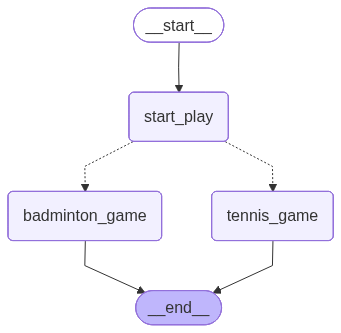

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

## build the graph
graph = StateGraph(State)


### adding the nodes to the graph

graph.add_node("start_play", start_play)
graph.add_node("badminton_game", badminton_game)
graph.add_node("tennis_game", tennis_game)
#### schedule the flow of the graph

graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", random_play)
graph.add_edge("badminton_game", END)
graph.add_edge("tennis_game", END)


### compile the graph
graph_builder = graph.compile()
### visualize the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

#

In [10]:
graph_builder.get_graph().print_ascii()

                +-----------+                 
                | __start__ |                 
                +-----------+                 
                       *                      
                       *                      
                       *                      
                +------------+                
                | start_play |                
                +------------+                
               ..            ..               
             ..                ..             
           ..                    ..           
+----------------+           +-------------+  
| badminton_game |           | tennis_game |  
+----------------+           +-------------+  
               **            **               
                 **        **                 
                   **    **                   
                 +---------+                  
                 | __end__ |                  
                 +---------+                  


In [11]:
print(graph_builder.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	start_play(start_play)
	badminton_game(badminton_game)
	tennis_game(tennis_game)
	__end__([<p>__end__</p>]):::last
	__start__ --> start_play;
	start_play -.-> badminton_game;
	start_play -.-> tennis_game;
	badminton_game --> __end__;
	tennis_game --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [22]:
graph_builder.invoke({"graph_info": "Hello my name is Krish "})

Start_play node has been called
Badminton game node has been called


{'graph_info': 'Hello my name is Krish I am planing to play a game badminton'}

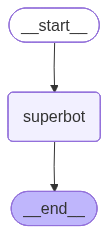

In [ ]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(
    model="gpt-4o",
    temperature=0.0,
    api_key=openai_token,
    base_url=openai_base_url,
)

### reducers

from typing import Annotated
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]


### we will start creating nodes
def superbot(state: State):
    return {"messages": [llm_model.invoke(state["messages"])]}


graph = StateGraph(State)
graph.add_node("superbot", superbot)
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)


graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
graph_builder.invoke({"messages": "Hi my name is krish, I like football"})

{'messages': [HumanMessage(content='Hi my name is krish, I like football', additional_kwargs={}, response_metadata={}, id='c33f6f68-8a9f-4098-a595-4360516c2a0c'),
  AIMessage(content="Hi Krish! It's great to meet you. Football is an exciting sport with a lot of action and strategy. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 17, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_11da807510', 'id': 'chatcmpl-DLSzgsBBsyqrqsYckRAgphFXer7UR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d0b28-b797-7a71-809c-ac6bdd630742-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inp

In [ ]:
#### straming the response
for event in graph_builder.stream(
    {"messages": "Hi my name is krish, I like football"}, stream_mode="values"
):
    print(event)

{'messages': [HumanMessage(content='Hi my name is krish, I like football', additional_kwargs={}, response_metadata={}, id='4b3625d6-833e-4546-b0c0-ca367b3dfd76')]}
{'messages': [HumanMessage(content='Hi my name is krish, I like football', additional_kwargs={}, response_metadata={}, id='4b3625d6-833e-4546-b0c0-ca367b3dfd76'), AIMessage(content="Hi Krish! It's great to meet you. Football is an exciting sport with a lot of action and strategy. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 17, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_11da807510', 'id': 'chatcmpl-DLT2CjqO2vhNXVBk66si8kdXmp60z', 'service_tier': 'def

#### State Schema with TypedDict
- When we define a Langgraph stategraph, we use a state schema.
- The state schema represents the structure and types od data that our graph will use.
- A;ll nodes are expected to communicate with that schema.
- Langgraph offers flexibility in how you define your state schema, accommodating various python types and validation approaches.


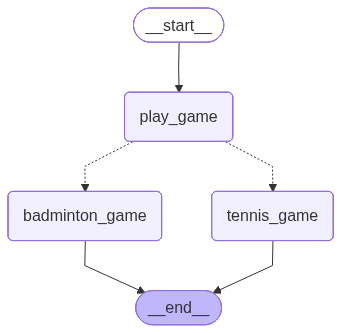

In [ ]:
from typing_extensions import TypedDict
from typing import Literal


class TypedDictState(TypedDict):
    name: Annotated[str, "name of the person"]
    game: Annotated[str, "game to play"]


def play_game(state: TypedDictState):
    print("----- play game node has been called -----")
    return {"name": state["name"], "game": "wantes to play "}


def badminton_game(state: TypedDictState):
    print("----- badminton game node has been called -----")
    return {"game": state["game"] + "badminton"}


def tennis_game(state: TypedDictState):
    print("----- tennis game node has been called -----")
    return {"game": state["game"] + "tennis"}


def random_play(state: TypedDictState) -> Literal["badminton_game", "tennis_game"]:
    if random.random() > 0.5:
        return "badminton_game"
    else:
        return "tennis_game"


builder_with_typeddict = StateGraph(TypedDictState)
builder_with_typeddict.add_node("play_game", play_game)
builder_with_typeddict.add_node("badminton_game", badminton_game)
builder_with_typeddict.add_node("tennis_game", tennis_game)

builder_with_typeddict.add_edge(START, "play_game")
builder_with_typeddict.add_conditional_edges("play_game", random_play)
builder_with_typeddict.add_edge("badminton_game", END)
builder_with_typeddict.add_edge("tennis_game", END)


builder_graph_with_typeddict = builder_with_typeddict.compile()
display(Image(builder_graph_with_typeddict.get_graph().draw_mermaid_png()))

In [60]:
builder_graph_with_typeddict.invoke({"name": "Biman"})

----- play game node has been called -----
----- tennis game node has been called -----


{'name': 'Biman', 'game': 'wantes to play tennis'}

#### State Schema with DataClass

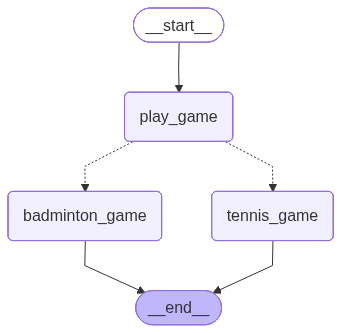

In [ ]:
from dataclasses import dataclass
from typing import Literal
from typing import Optional


@dataclass
class DataClassState:
    name: Annotated[str, "name of the person"]
    game: Optional[Annotated[str, "game to play"]] = None


def play_game(state: DataClassState):
    print("----- play game node has been called -----")
    return {"name": state.name, "game": "wantes to play "}


def badminton_game(state: DataClassState):
    print("----- badminton game node has been called -----")
    return {"game": state.game + "badminton"}


def tennis_game(state: DataClassState):
    print("----- tennis game node has been called -----")
    return {"game": state.game + "tennis"}


def random_play(state: DataClassState) -> Literal["badminton_game", "tennis_game"]:
    if random.random() > 0.5:
        return "badminton_game"
    else:
        return "tennis_game"


builder_with_dataclass = StateGraph(DataClassState)
builder_with_dataclass.add_node("play_game", play_game)
builder_with_dataclass.add_node("badminton_game", badminton_game)
builder_with_dataclass.add_node("tennis_game", tennis_game)

builder_with_dataclass.add_edge(START, "play_game")
builder_with_dataclass.add_conditional_edges("play_game", random_play)
builder_with_dataclass.add_edge("badminton_game", END)
builder_with_dataclass.add_edge("tennis_game", END)


builder_graph_with_dataclass = builder_with_dataclass.compile()
display(Image(builder_graph_with_dataclass.get_graph().draw_mermaid_png()))

In [61]:
builder_graph_with_dataclass.invoke(DataClassState(name="Biman"))

----- play game node has been called -----
----- tennis game node has been called -----


{'name': 'Biman', 'game': 'wantes to play tennis'}

#### Pydantic 

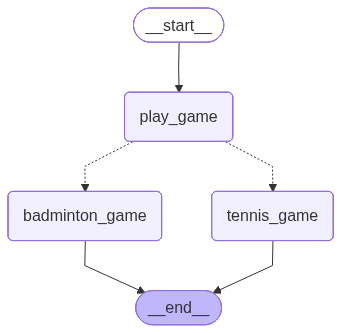

In [68]:
from pydantic import BaseModel, Field
from typing import Literal


class PydanticState(BaseModel):
    name: str = Field(description="name of the person")
    game: str = Field(description="game to play", default=None)


def play_game(state: PydanticState):
    print("----- play game node has been called -----")
    return {"name": state.name, "game": "wantes to play "}


def badminton_game(state: PydanticState):
    print("----- badminton game node has been called -----")
    return {"game": state.game + "badminton"}


def tennis_game(state: PydanticState):
    print("----- tennis game node has been called -----")
    return {"game": state.game + "tennis"}


def random_play(state: PydanticState) -> Literal["badminton_game", "tennis_game"]:
    if random.random() > 0.5:
        return "badminton_game"
    else:
        return "tennis_game"


builder_with_pydantic = StateGraph(PydanticState)
builder_with_pydantic.add_node("play_game", play_game)
builder_with_pydantic.add_node("badminton_game", badminton_game)
builder_with_pydantic.add_node("tennis_game", tennis_game)

builder_with_pydantic.add_edge(START, "play_game")
builder_with_pydantic.add_conditional_edges("play_game", random_play)
builder_with_pydantic.add_edge("badminton_game", END)
builder_with_pydantic.add_edge("tennis_game", END)


builder_graph_with_pydantic = builder_with_pydantic.compile()
display(Image(builder_graph_with_pydantic.get_graph().draw_mermaid_png()))

In [69]:
builder_graph_with_pydantic.invoke(PydanticState(name="Biman"))

----- play game node has been called -----
----- badminton game node has been called -----


{'name': 'Biman', 'game': 'wantes to play badminton'}

#### Chain Using LangGraph
In this section we will see how we can build a simple chain using LangGraph that uses 4 important concepts
- How to use chat messages as our graph state.
- How to use chat models in graph nodes.
- How to bind tools to our LLM in chat models.
- How to execute the tools call in our graph nodes.


In [76]:
from langchain_core.messages import HumanMessage, AIMessage
from pprint import pprint
messages = [AIMessage(content ="Please tell me how can I help you")]
messages.append(HumanMessage(content = "I want to learn how to do programming"))
messages.append(AIMessage(content = "Please tell me which language you want to learn"))
messages.append(HumanMessage(content = "I want to learn python"))
for message in messages:
    message.pretty_print()

================================== Ai Message ==================================

Please tell me how can I help you
================================ Human Message =================================

I want to learn how to do programming
================================== Ai Message ==================================

Please tell me which language you want to learn
================================ Human Message =================================

I want to learn python


In [80]:
from langchain_openai import ChatOpenAI
llm_model = ChatOpenAI(
    model="gpt-4o",
    temperature=0.0,
    api_key=openai_token,
    base_url=openai_base_url,
)
result = llm_model.invoke(messages)


In [81]:
result.pretty_print()

================================== Ai Message ==================================

Great choice! Python is a versatile and beginner-friendly programming language. Here’s a step-by-step guide to help you get started:

1. **Set Up Your Environment:**
   - **Install Python:** Download and install Python from the [official website](https://www.python.org/downloads/). Make sure to check the box that says "Add Python to PATH" during installation.
   - **Choose an IDE or Text Editor:** You can use an Integrated Development Environment (IDE) like PyCharm, or a text editor like Visual Studio Code, Sublime Text, or even the built-in IDLE that comes with Python.

2. **Learn the Basics:**
   - **Syntax and Variables:** Understand how to write basic Python syntax, and learn about variables and data types (integers, floats, strings, booleans).
   - **Control Structures:** Learn about conditionals (`if`, `else`, `elif`) and loops (`for`, `while`).
   - **Functions:** Learn how to define and call funct